<a href="https://colab.research.google.com/github/25041097-jesus/Probabilidad/blob/main/Unidad1/Practica%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Probabilidad y estadistica**

Unidad 1

**Practica 3: Tabla de frecuencias y regla de Sturges...**

Docente: Dr. Jose Gabriel Rodriguez Rivas

Alumno: Joan Jesus Varela Cervantes

Lista de edades: [18, 29, 29, 40, 21, 31, 22, 35, 22, 57, 42, 23, 68, 60, 28, 58, 36, 36, 60, 30, 57, 23, 22, 35, 23, 24, 56, 43, 54, 68, 23, 37, 45, 45, 42, 47, 21, 60, 59, 27, 48, 64, 50, 43, 49, 69, 44, 56, 32, 50, 70, 68, 32, 58, 68, 55, 39, 42, 62, 49, 32, 22, 54, 68, 37, 55, 19, 31, 51, 52, 58, 30, 61, 46, 70, 68, 45, 23, 55, 50, 66, 68, 20, 45, 23, 25, 42, 29, 60, 62, 53, 67, 23, 22, 67, 22, 65, 56, 23, 30]
Tabla de Distribución de Frecuencias:
    Edad  Frecuencia  Frec Relativa  Frec Porcentual  Frec Acumulada
26    18           1           0.01              1.0               1
38    19           1           0.01              1.0               2
43    20           1           0.01              1.0               3
13    21           2           0.02              2.0               5
2     22           6           0.06              6.0              11
0     23           8           0.08              8.0              19
30    24           1           0.01              1.0         

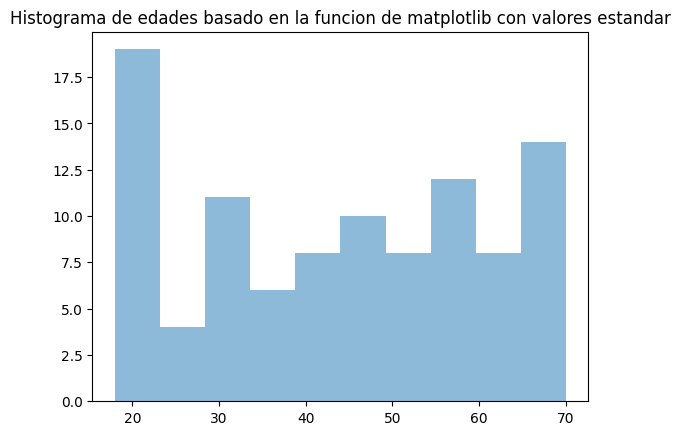

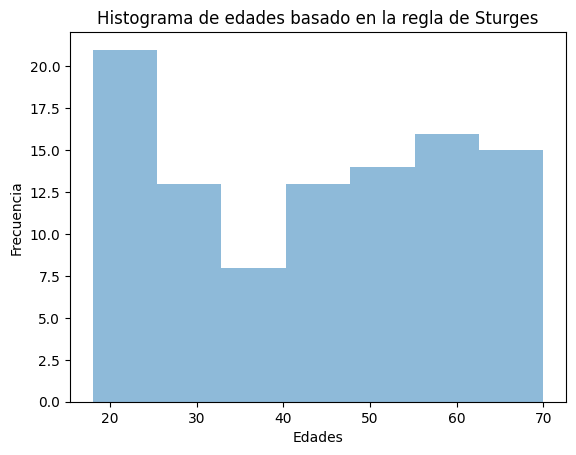

In [2]:
import math
import random
import pandas as pd

# 1. Generación de datos aleatorios
edades = []
for i in range(100):
  numero_aleatorio = random.randint(18, 70)
  edades.append(numero_aleatorio)

print("Lista de edades:", edades)

# 2. DataFrame inicial
df = pd.DataFrame(edades, columns=["Edad"])

# 3. Tabla de distribución de frecuencias simple
tabla_frecuencias = df["Edad"].value_counts().reset_index()
tabla_frecuencias.columns = ["Edad", "Frecuencia"]
tabla_frecuencias = tabla_frecuencias.sort_values(by="Edad")

# Cálculos de frecuencias
tabla_frecuencias["Frec Relativa"] = tabla_frecuencias["Frecuencia"] / 100
tabla_frecuencias["Frec Porcentual"] = (
    tabla_frecuencias["Frecuencia"] / 100
) * 100
tabla_frecuencias["Frec Acumulada"] = tabla_frecuencias["Frecuencia"].cumsum()

print("Tabla de Distribución de Frecuencias:")
print(tabla_frecuencias)

# 4. Aplicación de la Regla de Sturges
n = len(edades)
K = int(1 + math.log2(n))

print("Valor de n =", n)
print("Número de intervalos =", K)

# Crear la tabla de frecuencias por intervalos (clases)
tabla_frecuencia = (
    pd.cut(df["Edad"], bins=K, include_lowest=True)
    .value_counts()
    .reset_index()
)
tabla_frecuencia.columns = ["Clase", "Frec"]
tabla_frecuencia = tabla_frecuencia.sort_values(by="Clase")

# Generar columnas de la tabla agrupada
tabla_frecuencia["Frec Rel"] = tabla_frecuencia["Frec"] / n
tabla_frecuencia["Frec Porc"] = (tabla_frecuencia["Frec"] / n) * 100
tabla_frecuencia["Frec Ac"] = tabla_frecuencia["Frec"].cumsum()
tabla_frecuencia["Frec Rel Ac"] = tabla_frecuencia["Frec Rel"].cumsum()
tabla_frecuencia["Frec Porc Ac"] = tabla_frecuencia["Frec Porc"].cumsum()

print("\nTabla de Frecuencias Agrupada (Sturges):")
print(tabla_frecuencia)

# 5. Visualización de Histogramas
plt.figure()
plt.hist(edades, alpha=0.5)
plt.title(
    "Histograma de edades basado en la funcion de matplotlib con valores"
    " estandar"
)
plt.show()

plt.figure()
plt.hist(df["Edad"], bins=K, alpha=0.5)
plt.title("Histograma de edades basado en la regla de Sturges")
plt.xlabel("Edades")
plt.ylabel("Frecuencia")
plt.show()
